# Probabilistic Modeling with Bayes Net

In this assignment, you will work with probabilistic models known as Bayesian Networks to efficiently calculate the answer to probability questions concerning discrete random variables.

In [23]:
from utils.bayes_net import BayesNet, Node
import utils.vis as vis 

## Part 1: Design Bayesian Network

To start, design a basic probabilistic model for the following system:

There's a nuclear power plant in which an alarm is supposed to ring when the core temperature, indicated by a gauge, exceeds a fixed threshold. For simplicity, we assume that the temperature is represented as either high or normal. However, the alarm is sometimes faulty, and the gauge is more likely to fail when the temperature is high. Use the following Boolean variables in your implementation:

- A = alarm sounds
- F<sub>A</sub> = alarm is faulty
- G = gauge reading (high = True, normal = False)
- F<sub>G</sub> = gauge is faulty
- T = actual temperature (high = True, normal = False)

Assume that the following statements about the system are true:

1. The temperature gauge reads the correct temperature with 95% probability when it is not faulty and 20% probability when it is faulty. For simplicity, say that the gauge's "true" value corresponds with its "hot" reading and "false" with its "normal" reading, so the gauge would have a 95% chance of returning "true" when the temperature is hot and it is not faulty.
2. The alarm is faulty 15% of the time.
3. The temperature is hot (call this "true") 20% of the time.
4. When the temperature is hot, the gauge is faulty 80% of the time. Otherwise, the gauge is faulty 5% of the time.
5. The alarm responds correctly to the gauge 55% of the time when the alarm is faulty, and it responds correctly to the gauge 90% of the time when the alarm is not faulty. For instance, when it is faulty, the alarm sounds 55% of the time that the gauge is "hot" and remains silent 55% of the time that the gauge is "normal."

Design a bayesian network for this system and set the conditional probabilities for the necessary variables on the network using utils functions and classes to represent the nodes and conditional probability arcs connecting nodes.

The following cell is an example of designing a simple bayes net using utils:

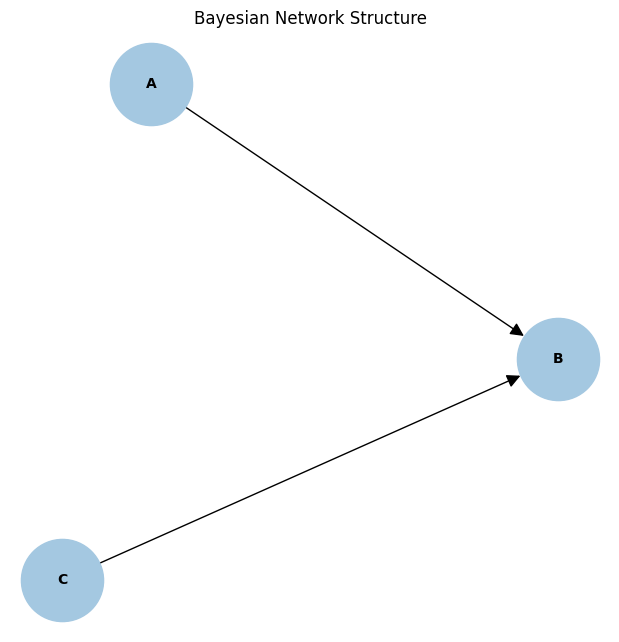

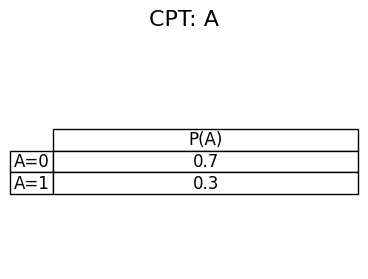

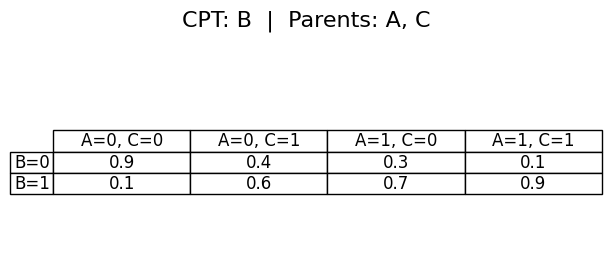

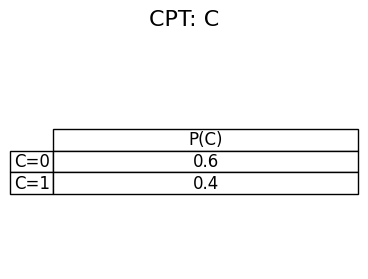

In [24]:
# Nodes
A = Node("A", [0, 1])
C = Node("C", [0, 1])
B = Node("B", [0, 1])

B.set_parents([A, C])

A.set_cpt([0.7, 0.3])
C.set_cpt([0.6, 0.4])
B.set_cpt([
    [[0.9, 0.4], [0.3, 0.1]], # P(B=0|A,C)
    [[0.1, 0.6], [0.7, 0.9]]  # P(B=1|A,C)
])

bn = BayesNet([A, B, C])

vis.plot_bayes_net(bn)
vis.plot_all_cpt_tables(bn)

In [25]:
def make_power_plant_net():
    # تعریف گره‌ها
    T = Node("temperature", [0, 1]) 
    Fa = Node("faulty alarm", [0, 1])
    Fg = Node("faulty gauge", [0, 1])
    G = Node("gauge", [0, 1])
    A = Node("alarm", [0, 1])

    # تعریف ساختار
    Fg.set_parents([T])
    G.set_parents([T, Fg])
    A.set_parents([G, Fa])
    
    bn = BayesNet([T, Fa, Fg, G, A])
    return bn

def set_probability(bn):
    T = next(n for n in bn.nodes if n.name == "temperature")
    Fa = next(n for n in bn.nodes if n.name == "faulty alarm")
    Fg = next(n for n in bn.nodes if n.name == "faulty gauge")
    G = next(n for n in bn.nodes if n.name == "gauge")
    A = next(n for n in bn.nodes if n.name == "alarm")

    # 1. Temperature (تک متغیره است، فرمتش ساده است)
    # P(T=0)=0.80, P(T=1)=0.20
    T.set_cpt([0.80, 0.20])

    # 2. Faulty Alarm (تک متغیره)
    # P(Fa=0)=0.85, P(Fa=1)=0.15
    Fa.set_cpt([0.85, 0.15])

    # 3. Faulty Gauge (Fg) - وابسته به T
    # ساختار باید این باشد: [ [احتمالات وقتی Fg=0], [احتمالات وقتی Fg=1] ]
    # وقتی Fg=0 (سالم): اگر T=0 باشد 0.95، اگر T=1 باشد 0.20
    # وقتی Fg=1 (خراب): اگر T=0 باشد 0.05، اگر T=1 باشد 0.80
    Fg.set_cpt([
        [0.95, 0.20], # ردیف اول: احتمالات Fg=0 به ازای تمام حالات والد
        [0.05, 0.80]  # ردیف دوم: احتمالات Fg=1 به ازای تمام حالات والد
    ])

    # 4. Gauge (G) - وابسته به T, Fg
    # ساختار: [ [G=0 همه حالات والدین], [G=1 همه حالات والدین] ]
    # ترتیب والدین: T (بیرونی)، Fg (درونی)
    # ماتریس G=0:
    #   T=0: [Fg=0 -> 0.95, Fg=1 -> 0.20]
    #   T=1: [Fg=0 -> 0.05, Fg=1 -> 0.20] (چون وقتی دما داغه ولی سنسور خرابه، شانس اینکه نرمال نشون بده ۲۰ درصده)
    G.set_cpt([
        [ # تمام حالات برای G=0 (Normal Reading)
            [0.95, 0.20], # T=0 (Normal Temp) -> [Fg=0, Fg=1]
            [0.05, 0.20]  # T=1 (Hot Temp)    -> [Fg=0, Fg=1]
        ],
        [ # تمام حالات برای G=1 (Hot Reading)
            [0.05, 0.80], # T=0 (Normal Temp) -> [Fg=0, Fg=1] (متمم بالایی‌ها)
            [0.95, 0.80]  # T=1 (Hot Temp)    -> [Fg=0, Fg=1]
        ]
    ])

    # 5. Alarm (A) - وابسته به G, Fa
    # ساختار: [ [A=0 همه حالات والدین], [A=1 همه حالات والدین] ]
    # ترتیب والدین: G (بیرونی)، Fa (درونی)
    A.set_cpt([
        [ # تمام حالات برای A=0 (Silent)
            [0.90, 0.55], # G=0 -> [Fa=0 (Correct), Fa=1 (Silent 55%)]
            [0.10, 0.45]  # G=1 -> [Fa=0 (Wrong 10%), Fa=1 (Mute?? No wait)]
            # توضیح G=1, Fa=1: آژیر خرابه و ۵۵٪ به گیج واکنش میده. یعنی ۵۵٪ زنگ میزنه. پس ۴۵٪ ساکته.
        ],
        [ # تمام حالات برای A=1 (Sounding)
            [0.10, 0.45], # G=0 -> [Fa=0 (Wrong), Fa=1 (Sound 45%)]
            [0.90, 0.55]  # G=1 -> [Fa=0 (Correct), Fa=1 (Sound 55%)]
        ]
    ])
    
    return bn

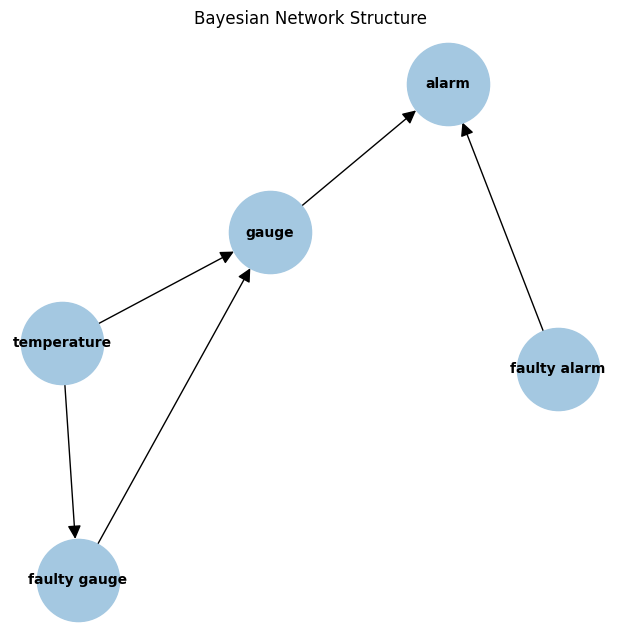

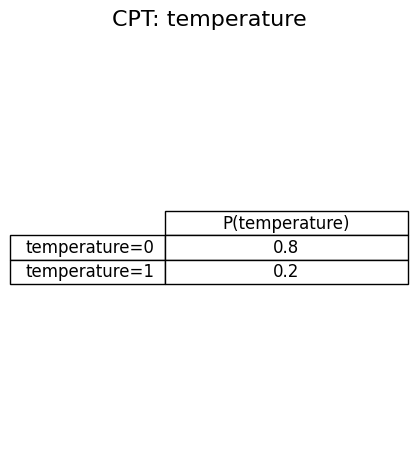

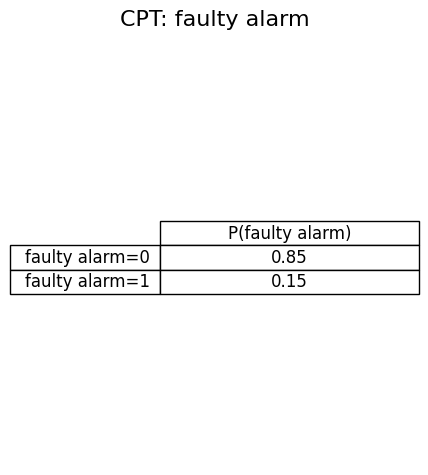

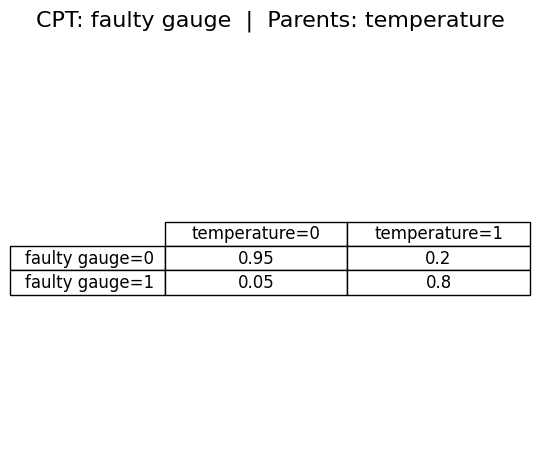

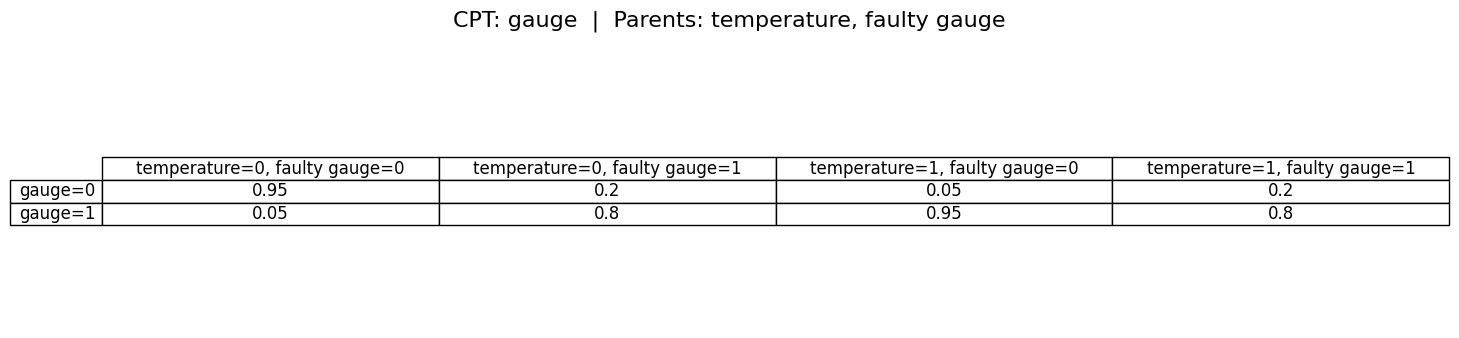

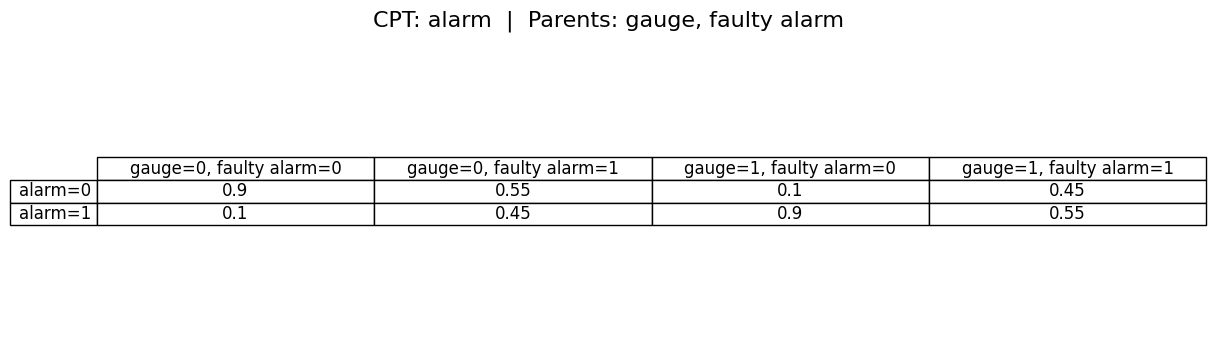

In [26]:
bn = make_power_plant_net()
bn = set_probability(bn)
vis.plot_bayes_net(bn)
vis.plot_all_cpt_tables(bn)


## Part 2: Exact Inference

In this part, you will compute probabilities using your Bayesian Network and exact methods.

You must implement:
- **Inference by Enumeration**
- **Inference by Variable Elimination**

You will also need **joint probability computation** when required so you must implement that too.

---

### Required Queries

Using both inference methods, compute:

- **Marginal probability the alarm sounds**  
  P(A = True)

- **Marginal probability the gauge reads hot**  
  P(G = True)

- **Posterior probability that the temperature is hot given evidence**  
  P(T = True ∣ A=True, Fa=False, Fg=False)

---

### What You Must Implement

✔ A function to compute **joint probability** using the whole network  
✔ `enumeration_ask(query_var, evidence, bn)`  
✔ `variable_elimination(query_var, evidence, bn)`  

For each query, print:
- Probability result using Enumeration
- Probability result using Variable Elimination
- Compare → Confirm that both methods match


In [27]:
import itertools

def get_node_prob(node, value, parent_values):
    """Helper to retrieve probability P(node=value | parents=parent_values) from CPT."""
    cpt = node.cpt[value]
    # Descend into the CPT based on parent values
    # Assuming parents are ordered in the CPT same as node.parents
    for p in node.parents:
        p_val = parent_values[p.name]
        cpt = cpt[p_val]
    return cpt

def joint_probability(bn, assignment):
    """
    Compute the joint probability P(X1, X2, ..., Xn) for a full assignment.
    """
    prob = 1.0
    for node in bn.nodes:
        val = assignment[node.name]
        # Get parent values for this node
        parent_vals = {p.name: assignment[p.name] for p in node.parents}
        prob *= get_node_prob(node, val, parent_vals)
    return prob

def enumeration_ask(query_var, evidence, bn):
    """
    Compute the probability distribution over query_var given evidence using enumeration.
    """
    # Identify variables
    query_node = next(n for n in bn.nodes if n.name == query_var)
    vars_list = bn.nodes # Ordered list of variables
    
    Q_dist = {}
    
    for val in query_node.values:
        # Extend evidence with the query variable's current value
        extended_evidence = evidence.copy()
        extended_evidence[query_var] = val
        
        # Sum over all hidden variables
        # Hidden variables are those not in evidence and not the query variable
        hidden_vars = [n for n in bn.nodes if n.name not in extended_evidence]
        
        total_prob = 0.0
        
        # Iterate over all possible combinations of hidden variables
        if not hidden_vars:
            total_prob = joint_probability(bn, extended_evidence)
        else:
            hidden_names = [n.name for n in hidden_vars]
            hidden_values_ranges = [n.values for n in hidden_vars]
            
            for config in itertools.product(*hidden_values_ranges):
                current_assignment = extended_evidence.copy()
                for i, name in enumerate(hidden_names):
                    current_assignment[name] = config[i]
                
                total_prob += joint_probability(bn, current_assignment)
        
        Q_dist[val] = total_prob
    
    # Normalize
    total_sum = sum(Q_dist.values())
    for k in Q_dist:
        Q_dist[k] /= total_sum
        
    return Q_dist

def variable_elimination(query_var, evidence, bn):
    """
    Compute the probability distribution over query_var given evidence using Variable Elimination.
    """
    factors = []
    
    # 1. Initialize factors for each CPT (Fixed Logic)
    for node in bn.nodes:
        # Full dependencies for the node (parents + itself)
        full_vars = [p for p in node.parents] + [node]
        
        # We only want variables in the factor scope if they are NOT in evidence
        # Evidence variables are treated as constants
        scope_vars = [v for v in full_vars if v.name not in evidence]
        scope = tuple([v.name for v in scope_vars])
        
        factor_table = {}
        ranges = [v.values for v in scope_vars]
        
        # Iterate over all configurations of the NON-evidence variables
        for assignment_tuple in itertools.product(*ranges):
            # Create a partial assignment from the iteration
            assignment_dict = {name: val for name, val in zip(scope, assignment_tuple)}
            
            # Add the fixed evidence values to the assignment
            # (So we can look up the probability correctly)
            full_assignment = assignment_dict.copy()
            full_assignment.update(evidence)
            
            # Now retrieve the probability P(node | parents)
            node_val = full_assignment[node.name]
            parent_vals = {p.name: full_assignment[p.name] for p in node.parents}
            
            prob = get_node_prob(node, node_val, parent_vals)
            
            factor_table[assignment_tuple] = prob

        factors.append({'scope': scope, 'table': factor_table})

    # 2. Eliminate hidden variables
    hidden_vars = [n.name for n in bn.nodes if n.name != query_var and n.name not in evidence]
    
    for var in hidden_vars:
        relevant_factors = [f for f in factors if var in f['scope']]
        if not relevant_factors:
            continue
            
        factors = [f for f in factors if f not in relevant_factors]
        
        # Compute new factor scope
        new_scope_set = set()
        for f in relevant_factors:
            new_scope_set.update(f['scope'])
        new_scope_set.remove(var)
        new_scope = tuple(sorted(list(new_scope_set)))
        
        new_table = {}
        
        # Get nodes for new scope to define ranges
        new_scope_nodes = [next(n for n in bn.nodes if n.name == s) for s in new_scope]
        ranges = [n.values for n in new_scope_nodes]
        
        # Get domain of the variable being eliminated
        var_node = next(n for n in bn.nodes if n.name == var)
        
        for config in itertools.product(*ranges):
            config_dict = {name: val for name, val in zip(new_scope, config)}
            sum_prob = 0.0
            
            for val in var_node.values:
                full_config_dict = config_dict.copy()
                full_config_dict[var] = val
                
                prod = 1.0
                for f in relevant_factors:
                    # Create key for this factor based on its specific scope
                    key = tuple(full_config_dict[s] for s in f['scope'])
                    prod *= f['table'].get(key, 0.0)
                sum_prob += prod
                
            new_table[config] = sum_prob
            
        factors.append({'scope': new_scope, 'table': new_table})
        
    # 3. Multiply remaining factors
    final_dist = {}
    query_node = next(n for n in bn.nodes if n.name == query_var)
    
    for val in query_node.values:
        prod = 1.0
        for f in factors:
            if query_var in f['scope']:
                # Scope should effectively be just (query_var,) at this point
                key = (val,)
                prod *= f['table'].get(key, 0.0)
            else:
                 # If factor has no variables (scalar), multiply it in
                 if len(f['table']) > 0:
                     # Usually has key () -> value
                     prod *= list(f['table'].values())[0]
        final_dist[val] = prod

    # Normalize
    total = sum(final_dist.values())
    if total > 0:
        for k in final_dist:
            final_dist[k] /= total
            
    return final_dist

In [28]:
def enumeration_prob(query_var, value, evidence, bn):
    """
    Returns P(query_var=value | evidence) using enumeration.
    value: 0 or 1 (or whatever is in node.values)
    """
    dist = enumeration_ask(query_var, evidence, bn)
    return dist[value]


def variable_elimination_prob(query_var, value, evidence, bn):
    """
    Returns P(query_var=value | evidence) using variable elimination.
    value: 0 or 1 (or whatever is in node.values)
    """
    dist = variable_elimination(query_var, evidence, bn)
    return dist[value]

In [29]:
queries = [
    ("alarm", 1, {}, "P(alarm=True)"),
    ("gauge", 1, {}, "P(gauge=True)"),
    ("temperature", 1, {"alarm": 1, "faulty alarm": 0, "faulty gauge": 0}, 
    "P(temperature=True | alarm=True, faulty alarm=False, faulty gauge=False)")
]

for q_var, target, ev, label in queries:
    print(f"\n--- {label} ---")
    enum_res = enumeration_prob(q_var, target, ev, bn)
    ve_res = variable_elimination_prob(q_var, target, ev, bn)
    print(f"Enumeration : {enum_res:.3f}")
    print(f"Var. Elim.  : {ve_res:.3f}")



--- P(alarm=True) ---
Enumeration : 0.317
Var. Elim.  : 0.317

--- P(gauge=True) ---
Enumeration : 0.236
Var. Elim.  : 0.236

--- P(temperature=True | alarm=True, faulty alarm=False, faulty gauge=False) ---
Enumeration : 0.244
Var. Elim.  : 0.244


In [30]:
bn = make_power_plant_net()
bn = set_probability(bn)

queries = [
    ("alarm", 1, {}, "P(alarm=True)"),
    ("gauge", 1, {}, "P(gauge=True)"),
    ("temperature", 1, {"alarm": 1, "faulty alarm": 0, "faulty gauge": 0}, 
    "P(temperature=True | alarm=True, faulty alarm=False, faulty gauge=False)")
]

for q_var, target, ev, label in queries:
    print(f"\n--- {label} ---")
    enum_res = enumeration_prob(q_var, target, ev, bn)
    ve_res = variable_elimination_prob(q_var, target, ev, bn)
    print(f"Enumeration : {enum_res:.3f}")
    print(f"Var. Elim.  : {ve_res:.3f}")


--- P(alarm=True) ---
Enumeration : 0.317
Var. Elim.  : 0.317

--- P(gauge=True) ---
Enumeration : 0.236
Var. Elim.  : 0.236

--- P(temperature=True | alarm=True, faulty alarm=False, faulty gauge=False) ---
Enumeration : 0.244
Var. Elim.  : 0.244


## Part 3: Approximate Inference

Consider the following scenario: 

There are five frisbee teams (T1, T2, T3,...,T5). A match is played between teams Ti and Ti+1 to give a total of 5 matches, i.e. T1vsT2, T2vsT3, ..., T4vsT5, T5vsT1.

Each team can either win, lose, or draw in a match. Each team has a fixed but unknown skill level, represented as an integer from 0 to 3. Each match's outcome is probabilistically proportional to the difference in skill level between the teams.

We want to estimate the outcome of the last match (T5vsT1), given prior knowledge of other 4 matches. Rather than using inference, we will do so by sampling the network using three models: Rejection Sampling, Likelihood Weighting, and Gibbs Sampling.

First, work on a similar, smaller network! With just 3 teams. 

### 3.1) Build a smaller network with 3 teams

For the first sub-part, consider a smaller network with 3 teams : the Airheads, the Buffoons, and the Clods (A, B and C for short). 3 total matches are played. 
Build a Bayes Net to represent the three teams and their influences on the match outcomes. Assume the following variable conventions:

| variable name | description|
|---------|:------:|
|A| A's skill level|
|B | B's skill level|
|C | C's skill level|
|AvB | the outcome of A vs. B <br> (0 = A wins, 1 = B wins, 2 = tie)|
|BvC | the outcome of B vs. C <br> (0 = B wins, 1 = C wins, 2 = tie)|
|CvA | the outcome of C vs. A <br> (0 = C wins, 1 = A wins, 2 = tie)|

Assume that each team has the following prior distribution of skill levels:

|skill level|P(skill level)|
|----|:----:|
|0|0.15|
|1|0.45|
|2|0.30|
|3|0.10|

In addition, assume that the differences in skill levels correspond to the following probabilities of winning:

| skill difference <br> (T2 - T1) | T1 wins | T2 wins| Tie |
|------------|----------|---|:--------:|
|0|0.10|0.10|0.80|
|1|0.20|0.60|0.20|
|2|0.15|0.75|0.10|
|3|0.05|0.90|0.05|

In [31]:
def make_game_network():
    # Skills [0, 1, 2, 3]
    A = Node("A", [0, 1, 2, 3])
    B = Node("B", [0, 1, 2, 3])
    C = Node("C", [0, 1, 2, 3])
    
    # Matches [0=T1(First) Wins, 1=T2(Second) Wins, 2=Tie]
    AvB = Node("AvB", [0, 1, 2])
    BvC = Node("BvC", [0, 1, 2])
    CvA = Node("CvA", [0, 1, 2])
    
    # Set Parents
    AvB.set_parents([A, B])
    BvC.set_parents([B, C])
    CvA.set_parents([C, A])
    
    bn = BayesNet([A, B, C, AvB, BvC, CvA])
    return bn

def get_match_probs(skill_1, skill_2):
    """Returns [P(T1 win), P(T2 win), P(Tie)] based on skill difference."""
    diff = skill_2 - skill_1
    
    # Table logic
    # Diff | T1 | T2 | Tie
    # 0    | .1 | .1 | .8
    # 1    | .2 | .6 | .2
    # 2    | .15| .75| .10
    # 3    | .05| .90| .05
    
    table = {
        0: [0.10, 0.10, 0.80],
        1: [0.20, 0.60, 0.20],
        2: [0.15, 0.75, 0.10],
        3: [0.05, 0.90, 0.05]
    }
    
    if diff >= 0:
        return table[diff]
    else:
        # Symmetry: if skill_1 > skill_2 (diff < 0)
        # T1 is the stronger team. 
        # P(T1 win | diff = -k) = P(T2 win | diff = k)
        # P(T2 win | diff = -k) = P(T1 win | diff = k)
        base = table[abs(diff)]
        return [base[1], base[0], base[2]]

def set_probability(bn):
    # Priors for skills: 0:0.15, 1:0.45, 2:0.30, 3:0.10
    skill_prior = [0.15, 0.45, 0.30, 0.10]
    
    teams = ["A", "B", "C"]
    for t_name in teams:
        node = next(n for n in bn.nodes if n.name == t_name)
        node.set_cpt(skill_prior)
        
    # Match CPTs
    # Order of parents matters. For AvB, parents are A, B.
    # CPT[outcome][A_skill][B_skill] = Prob
    
    matches = [("AvB", "A", "B"), ("BvC", "B", "C"), ("CvA", "C", "A")]
    
    for match_name, t1_name, t2_name in matches:
        match_node = next(n for n in bn.nodes if n.name == match_name)
        
        # 3x4x4 nested list: [outcome][t1_skill][t2_skill]
        cpt = [[[0.0 for _ in range(4)] for _ in range(4)] for _ in range(3)]
        for s1 in range(4):
            for s2 in range(4):
                probs = get_match_probs(s1, s2)
                for o in range(3):
                    cpt[o][s1][s2] = probs[o]
        
        match_node.set_cpt(cpt)
        
    return bn

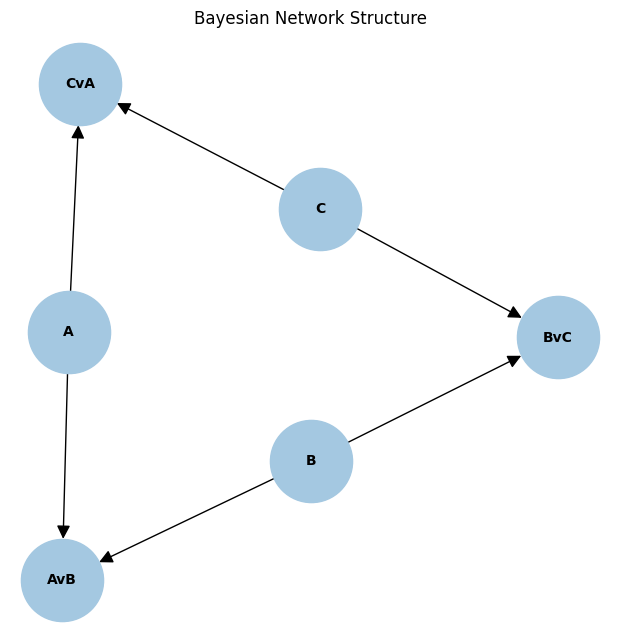

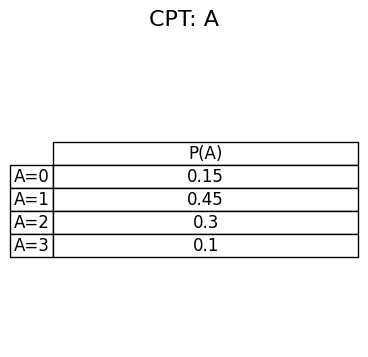

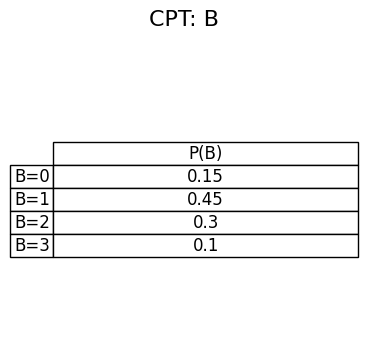

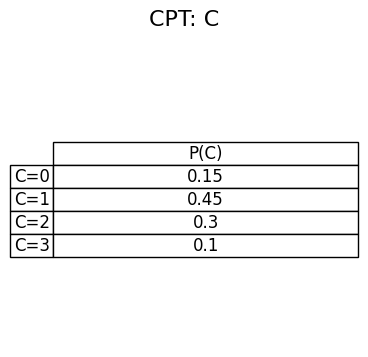

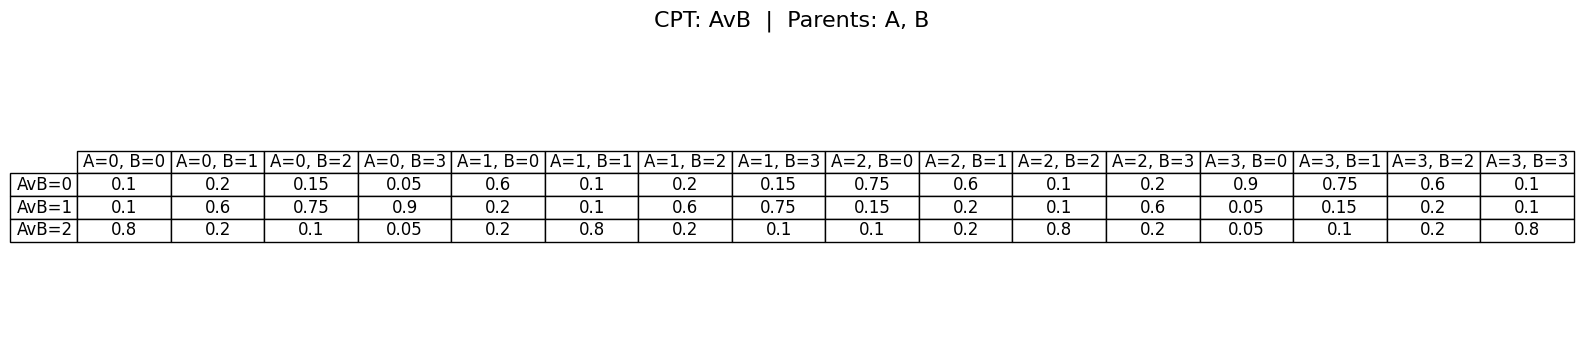

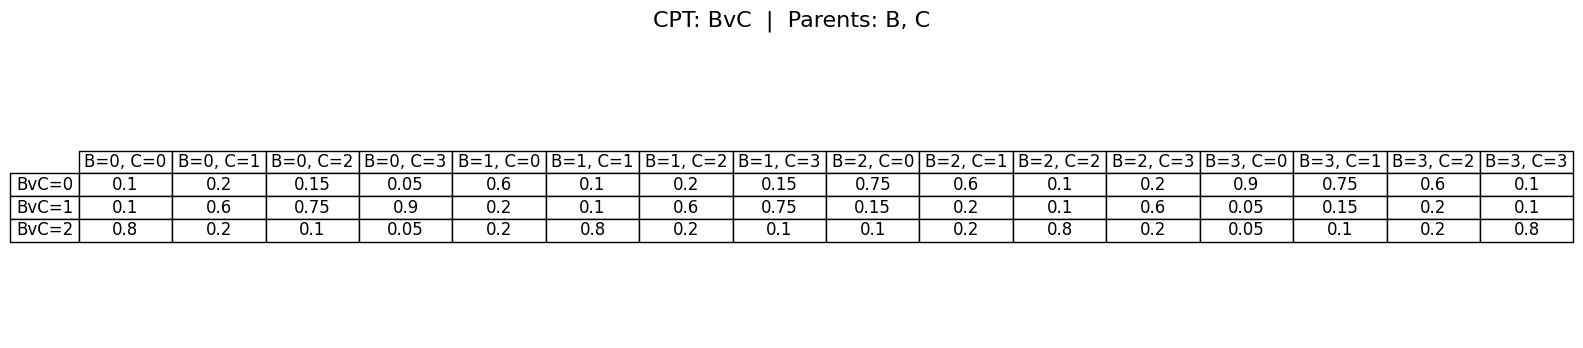

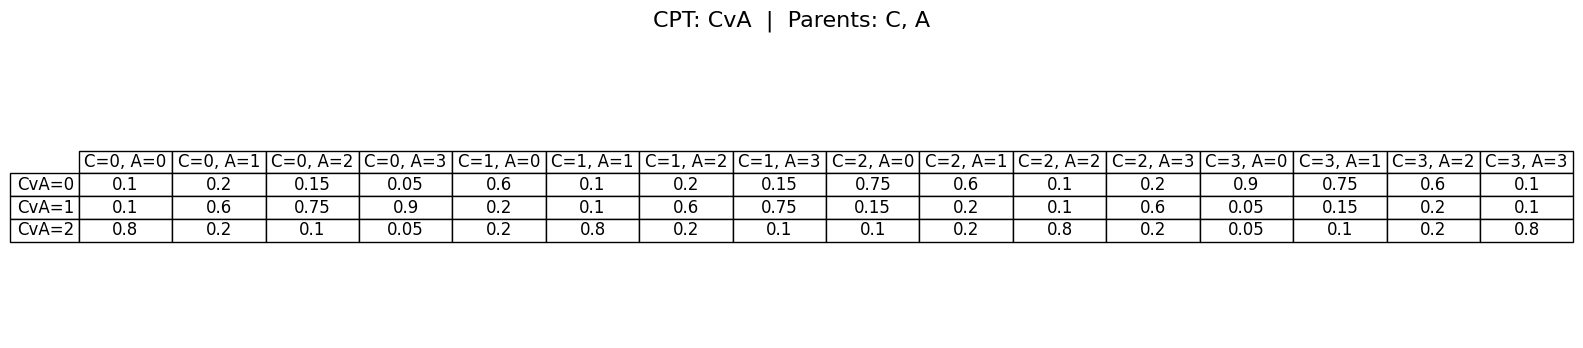

In [32]:
bn = make_game_network()
bn = set_probability(bn)
vis.plot_bayes_net(bn)
vis.plot_all_cpt_tables(bn)


### 3.2) Calculate posterior distribution for the 3rd match.

Suppose that you know the following outcome of two of the three games: A beats B and B draws with C. Start by calculating the posterior distribution for the outcome of the CvA match in calculate_posterior(). Use Enumeration ONLY. 

In [33]:
def calculate_posterior(bn):
    # Evidence: A beats B (AvB=0), B draws with C (BvC=2)
    evidence = {"AvB": 0, "BvC": 2}
    # Query: CvA
    return enumeration_ask("CvA", evidence, bn)

In [34]:
posterior = calculate_posterior(bn)
posterior

{0: np.float64(0.24532570995014094),
 1: np.float64(0.4579611966182528),
 2: np.float64(0.2967130934316062)}

### 3.3) Rejection Sampling

Now suppose you have 5 teams. You don't necessarily need to create a new network. You can just use the probability distributions tables from the previous part. Although be careful while indexing them.

Use **Rejection Sampling** to estimate the posterior probability of the 5th match (T5vT1). The algorithm works as follows:

1. Sample a full state (skills + matches) from the prior distribution.
2. Reject the sample if it is inconsistent with the evidence (the 4 known matches).
3. Keep track of how often each outcome occurs for the 5th match.
4. Normalize counts to get estimated probabilities.

Implement this in the function `rejection_sampling()`.


In [35]:
import random

def rejection_sampling(bayes_net, query_index, evidence, num_samples=10000, number_of_teams=5):
    # Assumes bayes_net is passed, but for 5 teams we might just use the logic directly 
    # since constructing the 5-team BN object isn't explicitly asked but implied.
    # However, to be generic, we'll assume we simulate the process using the rules.
    
    counts = [0.0] * 3 # [Win, Lose, Tie] for the query match
    
    # Skill prior cum_weights for fast sampling
    skill_vals = [0, 1, 2, 3]
    skill_probs = [0.15, 0.45, 0.30, 0.10]
    
    for _ in range(num_samples):
        # 1. Sample Skills for all teams
        skills = random.choices(skill_vals, weights=skill_probs, k=number_of_teams)
        
        # 2. Check Consistency with Evidence
        # Evidence keys are likely indices of matches. 
        # Match i is between T(i) and T((i+1)%N).
        # evidence map: {match_index: outcome}
        
        consistent = True
        for m_idx, outcome in evidence.items():
            t1 = skills[m_idx]
            t2 = skills[(m_idx + 1) % number_of_teams]
            
            probs = get_match_probs(t1, t2)
            # Sample match outcome
            sample_outcome = random.choices([0, 1, 2], weights=probs, k=1)[0]
            
            if sample_outcome != outcome:
                consistent = False
                break
        
        if consistent:
            # 3. Record Query Variable
            # Query index is the match index
            q_t1 = skills[query_index]
            q_t2 = skills[(query_index + 1) % number_of_teams]
            q_probs = get_match_probs(q_t1, q_t2)
            q_outcome = random.choices([0, 1, 2], weights=q_probs, k=1)[0]
            
            counts[q_outcome] += 1
            
    # Normalize
    total = sum(counts)
    if total == 0: return [0.0]*3
    return [c / total for c in counts]

### 3.4) Likelihood Weighting

Next, use **Likelihood Weighting** to estimate the posterior probability of the 5th match (T5vT1). 

The algorithm works as follows:

1. Sample only the non-evidence variables from their conditional distributions.
2. Assign a weight to the sample based on the probability of the evidence given the sampled values.
3. Aggregate the weighted counts for the query variable.
4. Normalize the weighted counts to get estimated probabilities.

Implement this in the function `likelihood_weighting()`.


In [36]:
def likelihood_weighting(bayes_net, query_index, evidence, num_samples=10000, number_of_teams=5):
    weighted_counts = [0.0] * 3
    skill_vals = [0, 1, 2, 3]
    skill_probs = [0.15, 0.45, 0.30, 0.10]
    
    for _ in range(num_samples):
        weight = 1.0
        
        # 1. Sample Skills (Always non-evidence in this specific problem formulation)
        skills = random.choices(skill_vals, weights=skill_probs, k=number_of_teams)
        
        # 2. Process Matches
        # If match is in evidence, accumulate weight. If not, sample it (if needed for downstream, but here matches are leaves)
        
        # Check evidence matches
        for m_idx, outcome in evidence.items():
            t1 = skills[m_idx]
            t2 = skills[(m_idx + 1) % number_of_teams]
            probs = get_match_probs(t1, t2)
            weight *= probs[outcome]
            
        # 3. Record Query
        # For the query match, we sample it from its distribution to count it
        # Or better: Add the probability distribution directly to the weighted sum (Rao-Blackwellised)
        # But standard LW samples the query variable.
        q_t1 = skills[query_index]
        q_t2 = skills[(query_index + 1) % number_of_teams]
        q_probs = get_match_probs(q_t1, q_t2)
        q_outcome = random.choices([0, 1, 2], weights=q_probs, k=1)[0]
        
        weighted_counts[q_outcome] += weight

    # Normalize
    total = sum(weighted_counts)
    if total == 0: return [0.0]*3
    return [c / total for c in weighted_counts]

### 3.5) Gibbs Sampling

Next, use **Gibbs Sampling** to estimate the posterior probability of a variable (e.g., the 5th match, T5vT1).

The algorithm works as follows:

1. Initialize the state: Assign random values to all non-evidence variables; fix evidence variables to their known values.
2. Iteratively update variables: At each step, pick one non-evidence variable and sample a new value conditioned on its Markov blanket (its parents, children, and children's other parents).
3. Track the query variable: Record the value of the query variable at each iteration.
4. Repeat for many iterations: Continue updating variables to allow the chain to approach the stationary distribution.
5. Normalize the counts: After all iterations (optionally discarding an initial burn-in period), normalize the counts of the query variable’s values to estimate posterior probabilities.

Implement this in the function `gibbs_sampling()`.

In [37]:
def gibbs_sampling(bayes_net, query_index, evidence, num_samples=10000, number_of_teams=5):
    counts = [0.0] * 3
    skill_vals = [0, 1, 2, 3]
    skill_probs_map = {0: 0.15, 1: 0.45, 2: 0.30, 3: 0.10}
    
    # 1. Initialize State (Random valid assignments)
    current_skills = random.choices(skill_vals, k=number_of_teams)
    
    # For matches: Evidence is fixed. Others are sampled random.
    # Note: Matches are children. In this graph, they don't influence each other directly, only via Skills.
    # Markov Blanket of a Skill Node S_i includes:
    # - Parents (None)
    # - Children (Match_{i-1, i}, Match_{i, i+1})
    # - Children's other parents (S_{i-1}, S_{i+1})
    
    # Burn-in
    burn_in = 1000
    
    for i in range(num_samples + burn_in):
        # Update each Skill variable S_k
        for k in range(number_of_teams):
            # Calculate P(S_k | Markov Blanket)
            # MB = {S_{k-1}, S_{k+1}, Match_{k-1, k}, Match_{k, k+1}}
            
            prev_team_idx = (k - 1) % number_of_teams
            next_team_idx = (k + 1) % number_of_teams
            
            s_prev = current_skills[prev_team_idx]
            s_next = current_skills[next_team_idx]
            
            # Evidence for the two matches involved
            # Match (k-1) vs k
            m_prev_idx = prev_team_idx
            m_prev_val = evidence.get(m_prev_idx) # May be None
            
            # Match k vs (k+1)
            m_next_idx = k
            m_next_val = evidence.get(m_next_idx) # May be None
            
            weights = []
            for val in skill_vals:
                # Prior P(S_k)
                p = skill_probs_map[val]
                
                # Likelihood from Match_{k-1, k}
                # If observed, multiply by P(Obs | S_{k-1}, S_k=val)
                # If unobserved, sum over outcomes? No, in Gibbs we sample unobserved vars too.
                # But here matches are leaves. Summing over leaves = 1. 
                # So unobserved matches don't affect parent probability!
                
                if m_prev_val is not None:
                    match_probs = get_match_probs(s_prev, val)
                    p *= match_probs[m_prev_val]
                    
                if m_next_val is not None:
                    match_probs = get_match_probs(val, s_next)
                    p *= match_probs[m_next_val]
                    
                weights.append(p)
            
            # Normalize and Sample new skill
            total_w = sum(weights)
            norm_weights = [w/total_w for w in weights]
            current_skills[k] = random.choices(skill_vals, weights=norm_weights, k=1)[0]
            
        # After updating skills, sample the query variable given the current state
        if i >= burn_in:
            q_t1 = current_skills[query_index]
            q_t2 = current_skills[(query_index + 1) % number_of_teams]
            q_probs = get_match_probs(q_t1, q_t2)
            
            # We can either sample outcome or accumulate probability (Rao-Blackwellized)
            # Sampling outcome to match strictly "Gibbs":
            q_outcome = random.choices([0, 1, 2], weights=q_probs, k=1)[0]
            counts[q_outcome] += 1

    # Normalize
    total = sum(counts)
    if total == 0: return [0.0]*3
    return [c / total for c in counts]

### 3.6) Compare Methods

Now that you have implemented sampling methods, you need to compare the prediction of these methods (approximate) with enumeration method (exact). First predict posterior probabilities for last match in a competetion of 3 teams with the same evidence as part 3.2 and then compare sampling results with enumeration.

After that predict posterior probabilities for last match in a competetion of 5 teams with the given evidence and show the difference between these methods.

Also test your sampling methods for other given evidence or number of teams and provide reason why your results correspond to the given evidence.

In [38]:
print("--- Comparison of Inference Methods (3 Teams) ---")

# 1. Exact Inference (Enumeration)
# Re-create the 3-team network if needed or use existing 'bn' from Part 3.1
bn_3team = make_game_network()
bn_3team = set_probability(bn_3team)

# Evidence: A beats B (AvB=0), B draws with C (BvC=2)
evidence_exact = {"AvB": 0, "BvC": 2}
# Query: CvA
exact_result_dict = enumeration_ask("CvA", evidence_exact, bn_3team)
# Convert dict to list [P(0), P(1), P(2)] for comparison
exact_probs = [exact_result_dict.get(0, 0), exact_result_dict.get(1, 0), exact_result_dict.get(2, 0)]

print(f"\nExact Inference (Enumeration):")
print(f"  CvA(0=C wins): {exact_probs[0]:.4f}, CvA(1=A wins): {exact_probs[1]:.4f}, CvA(2=Tie): {exact_probs[2]:.4f}")

# 2. Approximate Inference
# Mapping evidence to indices for sampling functions:
# Match 0: AvB (Outcome 0)
# Match 1: BvC (Outcome 2)
# Query Match 2: CvA
evidence_approx = {0: 0, 1: 2}
query_match_idx = 2
n_teams = 3
n_samples = 5000

print(f"\nApproximate Inference ({n_samples} samples):")

# Rejection Sampling
rs_probs = rejection_sampling(None, query_match_idx, evidence_approx, num_samples=n_samples, number_of_teams=n_teams)
print(f"  Rejection Sampling   : {rs_probs[0]:.4f}, {rs_probs[1]:.4f}, {rs_probs[2]:.4f}")

# Likelihood Weighting
lw_probs = likelihood_weighting(None, query_match_idx, evidence_approx, num_samples=n_samples, number_of_teams=n_teams)
print(f"  Likelihood Weighting : {lw_probs[0]:.4f}, {lw_probs[1]:.4f}, {lw_probs[2]:.4f}")

# Gibbs Sampling
gs_probs = gibbs_sampling(None, query_match_idx, evidence_approx, num_samples=n_samples, number_of_teams=n_teams)
print(f"  Gibbs Sampling       : {gs_probs[0]:.4f}, {gs_probs[1]:.4f}, {gs_probs[2]:.4f}")

# Error Calculation (Simple Absolute Error Sum)
def calc_error(true_p, approx_p):
    return sum(abs(t - a) for t, a in zip(true_p, approx_p))

print(f"\nErrors (Sum of Absolute Differences):")
print(f"  Rejection Error: {calc_error(exact_probs, rs_probs):.4f}")
print(f"  Likelihood Error: {calc_error(exact_probs, lw_probs):.4f}")
print(f"  Gibbs Error: {calc_error(exact_probs, gs_probs):.4f}")

--- Comparison of Inference Methods (3 Teams) ---

Exact Inference (Enumeration):
  CvA(0=C wins): 0.2453, CvA(1=A wins): 0.4580, CvA(2=Tie): 0.2967

Approximate Inference (5000 samples):
  Rejection Sampling   : 0.2829, 0.4252, 0.2919
  Likelihood Weighting : 0.2490, 0.4678, 0.2833
  Gibbs Sampling       : 0.2488, 0.4606, 0.2906

Errors (Sum of Absolute Differences):
  Rejection Error: 0.0751
  Likelihood Error: 0.0269
  Gibbs Error: 0.0122


In [39]:
print("--- Comparison of Approximate Methods (5 Teams) ---")

# Setup: 5 Teams
# Evidence: Let's assume a chain of wins.
# T0 beats T1 (Match 0 = 0)
# T1 beats T2 (Match 1 = 0)
# T2 beats T3 (Match 2 = 0)
# T3 beats T4 (Match 3 = 0)
# Query: Match 4 (T4 vs T0). Can T4 beat T0 after everyone else lost?
evidence_5team = {0: 0, 1: 0, 2: 0, 3: 0}
query_idx_5 = 4
n_teams_5 = 5
n_samples_5 = 10000

print(f"Evidence: T0>T1, T1>T2, T2>T3, T3>T4. Query: T4 vs T0")

# Run Samplers
rs_5 = rejection_sampling(None, query_idx_5, evidence_5team, num_samples=n_samples_5, number_of_teams=n_teams_5)
lw_5 = likelihood_weighting(None, query_idx_5, evidence_5team, num_samples=n_samples_5, number_of_teams=n_teams_5)
gs_5 = gibbs_sampling(None, query_idx_5, evidence_5team, num_samples=n_samples_5, number_of_teams=n_teams_5)

print(f"\nResults (Win, Lose, Tie) for T4 vs T0:")
print(f"  Rejection Sampling   : {rs_5[0]:.4f}, {rs_5[1]:.4f}, {rs_5[2]:.4f}")
print(f"  Likelihood Weighting : {lw_5[0]:.4f}, {lw_5[1]:.4f}, {lw_5[2]:.4f}")
print(f"  Gibbs Sampling       : {gs_5[0]:.4f}, {gs_5[1]:.4f}, {gs_5[2]:.4f}")

print("\nAnalysis Hint: With Rejection Sampling, if evidence probability is low, you might see fewer effective samples.")

--- Comparison of Approximate Methods (5 Teams) ---
Evidence: T0>T1, T1>T2, T2>T3, T3>T4. Query: T4 vs T0

Results (Win, Lose, Tie) for T4 vs T0:
  Rejection Sampling   : 0.1667, 0.5000, 0.3333
  Likelihood Weighting : 0.2136, 0.4589, 0.3276
  Gibbs Sampling       : 0.2229, 0.4557, 0.3214

Analysis Hint: With Rejection Sampling, if evidence probability is low, you might see fewer effective samples.


In [40]:
print("--- Testing with Different Evidence (High Tie Probability) ---")

# Let's test a scenario where Ties are observed, which are generally highly probable if skills are equal.
# 4 Teams.
# Matches: 0(T0-T1), 1(T1-T2), 2(T2-T3), 3(T3-T0)
# Evidence: Match 0 is Tie, Match 1 is Tie.
# Query: Match 3 (T3 vs T0)

evidence_ties = {0: 2, 1: 2} # Tie, Tie
query_idx_ties = 3
n_teams_ties = 4
n_samples_ties = 5000

print(f"Scenario: 4 Teams. T0=T1 and T1=T2. Predict T3 vs T0.")

rs_ties = rejection_sampling(None, query_idx_ties, evidence_ties, num_samples=n_samples_ties, number_of_teams=n_teams_ties)
lw_ties = likelihood_weighting(None, query_idx_ties, evidence_ties, num_samples=n_samples_ties, number_of_teams=n_teams_ties)
gs_ties = gibbs_sampling(None, query_idx_ties, evidence_ties, num_samples=n_samples_ties, number_of_teams=n_teams_ties)

print(f"\nResults for T3 vs T0:")
print(f"  Rejection Sampling   : {rs_ties[0]:.4f}, {rs_ties[1]:.4f}, {rs_ties[2]:.4f}")
print(f"  Likelihood Weighting : {lw_ties[0]:.4f}, {lw_ties[1]:.4f}, {lw_ties[2]:.4f}")
print(f"  Gibbs Sampling       : {gs_ties[0]:.4f}, {gs_ties[1]:.4f}, {gs_ties[2]:.4f}")

--- Testing with Different Evidence (High Tie Probability) ---
Scenario: 4 Teams. T0=T1 and T1=T2. Predict T3 vs T0.

Results for T3 vs T0:
  Rejection Sampling   : 0.3082, 0.2827, 0.4091
  Likelihood Weighting : 0.3006, 0.2868, 0.4126
  Gibbs Sampling       : 0.3090, 0.2880, 0.4030
